# MT3510 Project - Team 11 (My note)

## Introduction

An introduction with some context - e.g. what is known in the literature about the problems mathematically and computationally? What are their histories? How do they relate to other mathematical problems?

## Coding Tasks Part 1: Synchronization

(a) Test if a given DFA $A$ is synchronizing by using breadth-first search to find a constant transformation in the transition monoid $T_A$, if it exists.

(b) Test if a given DFA $A$ is synchronizing by using breadth-first search to find an image of size 1, if it exists. The same warning applies, to a lesser extent.

In [1]:
A = {
    "Q": {0, 1, 2},
    "Sigma": {"a", "b"},
    "tau": {
        'a':(1,2,2),
        'b':(0,0,1)
    },
    "q_s": 0,
    "F": {0}
}

from collections import deque
def synchronization_bfs_image(A): # enumerating images of transformations
    Q = tuple(A["Q"]) # changing Q to the set to tuple Q
    tau = A["tau"] # assing the name to tau
    Sigma = A["Sigma"] # assing the name to Sigma
    queue = deque([Q])# The deque means "double ended queue"; we will only care about
                    # putting things in at the end and "popping" them from the front.
                    # looking at the original Q in the first place

    seen = {Q} # already checked Q

    # a loop repeating while queue has entries 
    while queue:
        # Get the first thing in the queue
        current_Q = queue.popleft()

        if len(current_Q) == 1: # checking if the size of image equals to 1
            print("Synchronizing state is found and it is: ", current_Q) # if so, this is synchronized)
            return True

        for a in Sigma: # Repeating for length of sigma 
            t_a = tau[a]

            new_Q = tuple(sorted({t_a[q] for q in current_Q})) # finding new tuple using t_a(Q)

            if new_Q not in seen:
                print(f"Visited tuple {new_Q} for the first time")
                seen.add(new_Q)
                # Add all of the neighbours of new_Q to the end of the queue.
                queue.append(new_Q)

    return False # If after iterating through no transformation is found return false

synchronization_bfs_image(A)

Visited tuple (0, 1) for the first time
Visited tuple (1, 2) for the first time
Visited tuple (0,) for the first time
Visited tuple (2,) for the first time
Synchronizing state is found and it is:  (0,)


True

(c) Test if a given DFA $A$ is synchronizing using the pair graph.

(d) Using the "ancestors" method from Tutorial 6, have the breadth-first search in (b) return a shortest-length synchronizing word, if it exists.

(e) Have your pair-graph method return a reset word if one exists.

(f) How do the reset words obtained from (d) and (e) compare? Can you heuristically shorten the word obtained from (e) at all? It may not be realistic to entirely minimise the length of the word obtained, but provide some analysis of your heuristic. It is entirely reasonable to analyse a heuristic that doesn't seem to work, as long as you give a good justification for why it might be expected to work.

## Coding Tasks Part 2: Isomorphism

Implement, and demonstrate, functions which, given two DFAs  $A_1$ and $A_2$, test for:

(a) Strict isomorphism

(b) Weak isomorphism

(c) Semi-isomorphism

as defined above. The interface to this functionality is up to you (as long as it accepts DFAs in the form specified above). You should consider (and implement) ways of making your code more efficient. Note that these three sub-tasks may share a lot of common code, and you should typically avoid code duplication.

In part (c) you should assume that in each input automata there is at least one state from which all other states are reachable. You may find the functionality in NetworkX for Strongly Connected Components and Condensations useful for identifying such states.

(d) Discuss to what extent each of these notions of isomorphism preserve synchronization properties of a DFA (if at all).

## Coding/Writing Tasks Part 3: Originality/Initiative

The project has marks dedicated to original / beyond specifications work. The following are intended to give guidance on the sort of things you might do.

・Provide visualizations (interactive or animated) of words synchronizing a DFA

・Discuss/implement canonicalisation or minimisation of DFAs, and how it relates to isomorphism

・Test probabilities of uniformly-chosen DFAs being synchronizing

・Some topic in formal language theory

・Replace the queue in the breadth-first search in 1(b) with a priority queue, so that you always explore from the smallest　images first. Analyse the differences.
...

[0, 1, 2]


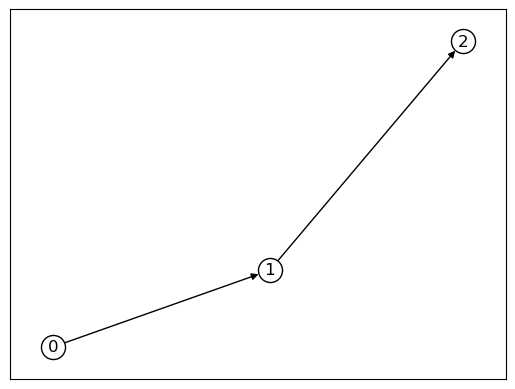

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# Make a graph with edges {0, 1}, and {1, 2}
D = nx.DiGraph([{0, 1}, {1, 2}])

# Draw the graph with white vertices and black vertex borders
nx.draw_networkx(D, node_color="w", edgecolors="k")

# Compute shortest path length from A to F ignoring weights
unweighted_path = nx.shortest_path(D, source = 0, target = 2)
print(unweighted_path)

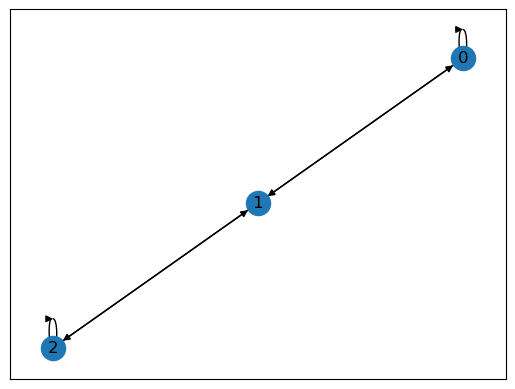

In [3]:
# Make a graph with edges {0, 1}, and {1, 2}
D = nx.DiGraph()

# a transitions
D.add_edge(0,1)
D.add_edge(1,2)
D.add_edge(2,2)

# b transitions
D.add_edge(0,0)
D.add_edge(1,0)
D.add_edge(2,1)

# Draw the graph 
nx.draw_networkx(D)

In [4]:
A = {
    "Q":{0,1,2,3},
    "sigma":{"0","1"},
    "tau":{
        (3,0):2,
        (3,1):0,
        (0,1):0,
        (0,0):1,
        (1,1):2,
        (1,0):0,
        (2,1):0,
        (2,0):1
    },
    "q_s":3,
    "F":{1,2}
} #example on the guideline